# Trabajo Práctico 1 - Cálculo de Ranking Page

## Enunciado

### Pregunta 1 - ¿Por que la matriz A definida en (4) es equivalente a $p \ \mathbf{W} \ \mathbf{D} + e \ z^t$ ? Justificar.

Que dos matrices sean iguales, es equivalente a decir que cada elemento en la posición ij es igual al elemento en la posición ij de la matriz $p \ \mathbf{W} \ \mathbf{D} + e \ z^t$
Entonces, sabiendo que A, está definida como la matriz donde sus elementos son de la siguiente forma:

\begin{equation*}
a_{ij} = \begin{cases}
\frac{(1-p)}{n}+ \frac{p \cdot w_{ij}}{c_j} & \text{si } c_j \neq 0 \\
\frac{1}{n} & \text{si } c_j = 0
\end{cases}
\end{equation*}

y cuales son los elementos de  $p \ \mathbf{W} \ \mathbf{D} + e \ z^t$, escribiendo a los elementos de dicha matriz en la posicion $ij$ llegamos a lo siguiente:

\begin{equation*}(p \ \mathbf{W} \ \mathbf{D} + e \ z^t)_{ij} = (pW_{ij}d_{jj} + e_{i}z_{j}^{t} ) ~~ con ~~1 ≤ i,j ≤ n
\end{equation*}
Como sabemos que de acuerdo al valor de $c_{j}$, el cual representa los links salientes de cada página, varían los valores de $z_{j}^t$ y $D$, siendo de la siguiente manera

\begin{align*}
d_{jj} &= \begin{cases}
\frac{1}{c_j} & \text{si } c_{j} \neq 0 \\
0 & \text{si } c_{j} = 0
\end{cases} \\
z_{j} &= \begin{cases}
\frac{(1 - p)}{n}  & \text{si } c_{j} \neq 0 \\
\frac{1}{n} & \text{si } c_{j} = 0
\end{cases}
\end{align*}


separamos en casos

* $c_{j} $ ≠ 0
Tenemos que :    

\begin{equation*}
p w_{ij}* \frac{1}{j} + \frac{(1-p)}{n}
\end{equation*}
Lo que es exactamente igual a $a_{ij}$ cuando $c_{j} $ ≠ 0

* $c_{j} = 0$

Tenemos que:

\begin{equation*}
pw_{ij}*0 + \frac{1}{n} = \frac{1}{n}
\end{equation*}

Lo que es igual a $a_{ij}$ cuando $c_{j} = 0$.

Por lo tanto, queda demostrado la equivalencia entre las escrituras de la matriz $\mathbf{A}$



### Pregunta 2 -  ¿Cómo se garantiza existencia de la factorización $LU$? ¿ La matriz $(\mathbf{I} - p \ \mathbf{W} \ \mathbf{D})$ está bien condicionada? ¿Cómo influye el valor de $p$?

La existencia de la factorización LU, se da cuando la matriz es inversible, lo que es análogo a pedir $\mathbf{det}(\mathbf{I} - p \ \mathbf{W} \ \mathbf{D})≠0$, y además sus menores principales deben ser no nulos.




---

Implementar la factorización $LU$ para resolver el sistema de ecuaciones (6) que permite hallar la solución buscada (es decir, el ranking de páginas). Se podrá utilizar la función **scipy.linalg.solve_triangular** para resolver sistemas triangulares.

En el siguiente cuerpo de la notebook se genera un test que va a evaluar la función que resuelve el sistema a través de un test unitario. La resolución debe realizarse en el archivo **funciones.py** que acompaña el **template-alumnos**.

## Implementación

In [70]:
from funciones import *

### Test Unitario
En el archivo funciones.py hay que implementar la función que obtienen el ranking de las páginas.
Se espera que el llamado a la siguiente función arroje un valor esperado

**************************************************
Test unitario 1
BIEN! - Paso correctamente el test unitario
**************************************************


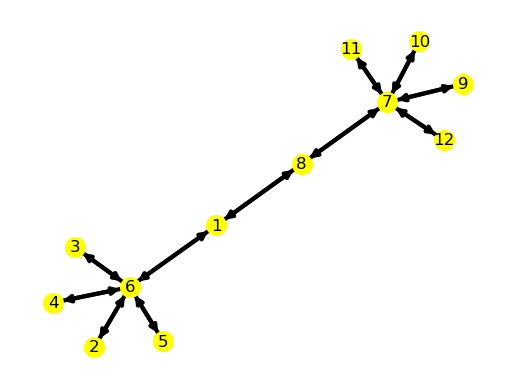

In [37]:
#ARCHIVOS DE ENTRADA
archivo_test = './tests/test_dosestrellas.txt'

#CARGA DE ARCHIVO EN GRAFO
W = leer_archivo(archivo_test)

dibujarGrafo(W, print_ejes=False)

# defino la probabilidad de salto de continuar los links de la pagina actual
p = 0.5
# Realizo el test unitario para el calculo del mayor score, que pruebe que el codigo funciona correctamente.
print('*'*50)
print('Test unitario 1')
try:
     assert(np.isclose(int(obtenerMaximoRankingScore(W,p)*(10**4))/(10**4), 0.1811))
except:
    print('OUCH!! - No paso el test unitario')
else:
    print('BIEN! - Paso correctamente el test unitario')
print('*'*50)


### Test Unitarios Adicionales

El grupo **deberá** proponer al menos 3 instancias de prueba no triviales, dos de las cuales deben ser de tipo TODOS LOS NODOS CONECTADOS, y otra de tipo NINGUNO CONECTADO. La tercera instancia queda a criterio del grupo.

Para el análisis, guiarse y responder las siguientes preguntas:

* ¿Cómo es el ranking obtenido en cada caso de acuerdo a la estructura del grafo páginas?
* ¿Qué conclusiones pueden sacar de la interpretación de los resultados?

Graficar los grafos usando las funciones en el **funciones.py**.

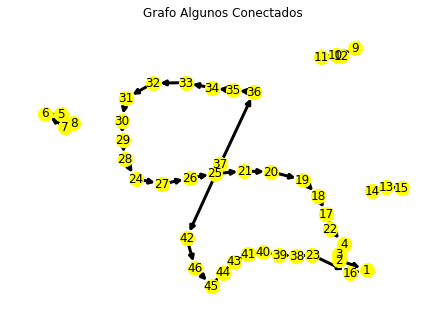
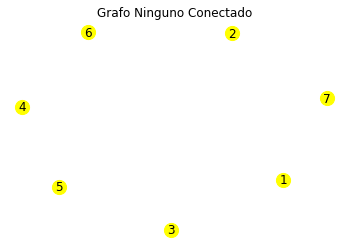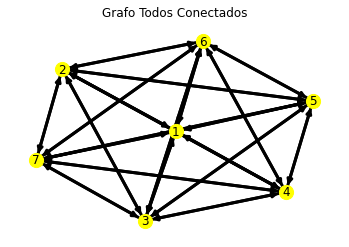



In [40]:
p = 0.5
rnk,scr = calcularRanking(matriz_todos_conectados, p)

print('===================================')
print('Resultados del test Todos Conectados')
print('===================================')
print('ranking: ', rnk)
print('Puntajes: ', scr)



NameError: name 'matriz_todos_conectados' is not defined

In [ ]:
p=0.5
rnk,scr = calcularRanking(matriz_ninguno_conectado, p)
print('===================================')
print('Resultados del test Ninguno Conectado')
print('===================================')
print('ranking: ', rnk)
print('Puntajes: ', scr)


NameError: name 'calcularRanking' is not defined

In [ ]:
nombre_archivo = "test_algunos_conectados"
num_paginas = 46  
generar_archivo_txt(W, nombre_archivo)
matriz_algunosconectados = leer_archivo(nombre_archivo)

dibujarGrafo(matriz_algunosconectados,titulo = 'Grafo ',print_ejes=False)

p=0.5
rnk,scr = calcularRanking(matriz_algunos_conectados, p)
print('===================================')
print('Resultados del test Algunos Conectados')
print('===================================')
print('ranking: ', rnk)
print('Puntajes: ', scr)

---

## Enunciado

Sobre los casos de test que se encuentran en el folder `tests`, se pide realizar los análisis siguientes para todos los grafos del folder.

### Análisis Cuantitativo

Para el análisis cuantitativo, se pide, como mínimo, estudiar los tiempos de procesamiento en función del tamaño del grafo de páginas y de la densidad del mismo. Para esto, se espera que presenten gráficos mostrando los tiempos de ejecución para obtener la solución en función de la cantidad de nodos/links de diferentes grafos de páginas aleatorios.


---


Para investigar el impacto del tamaño de la matriz de conectividad y la cantidad de links en el tiempo de ejecución, generamos matrices aleatorias utilizando dos enfoques distintos: uno mantiene fija la cantidad de páginas y varía la cantidad de enlaces, mientras que el otro mantiene fija la cantidad de enlaces y varía la cantidad de páginas.

A continuación, se exponen las características estadísticas distintivas de los dos enfoques. En el caso de páginas fijas, se examinó una muestra de 211 matrices con una progresiva variación en la cantidad de links. De este análisis, se observa que la diferencia entre el tiempo de ejecución mínimo y máximo es menor a 1 ms, con un promedio de aproximadamente 1 ms. Por otro lado, en el enfoque de links fijos, se seleccionó una muestra de 25 matrices que experimentan una variación progresiva en la cantidad de links. En este caso, se registró una diferencia de casi 3 ms entre el tiempo de ejecución mínimo y máximo, con un promedio cercano a 1.5 ms. Estos criterios se eligieron con el fin de explorar toda la variación posible en cada caso, al mismo tiempo que se consideraban las limitaciones de la máquina utilizada para realizar el análisis de manera eficiente.

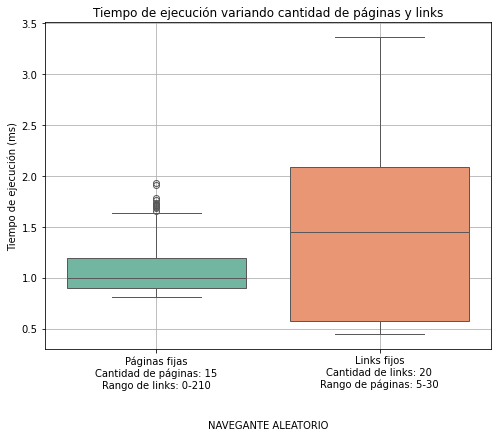

Además de analizar las matrices mencionadas anteriormente, examinamos las variaciones en los tiempos de ejecución utilizando los datos de los tests provistos. En esta instancia, comparamos los tiempos obtenidos al calcular los rankings con el modelo estándar (en el que no se considera el parámetro p) y el modelo del navegante aleatorio. Para representar todos los factores involucrados, elegimos un gráfico de burbujas, donde el tamaño de la burbuja refleja la magnitud del tiempo requerido. En el eje x, representamos la cantidad de links, mientras que en el eje y, la cantidad de páginas. Dado que cuatro de los tests mostraron diferencias significativamente pequeñas respecto a los otros dos, añadimos un subgráfico que cumple la función de zoom.



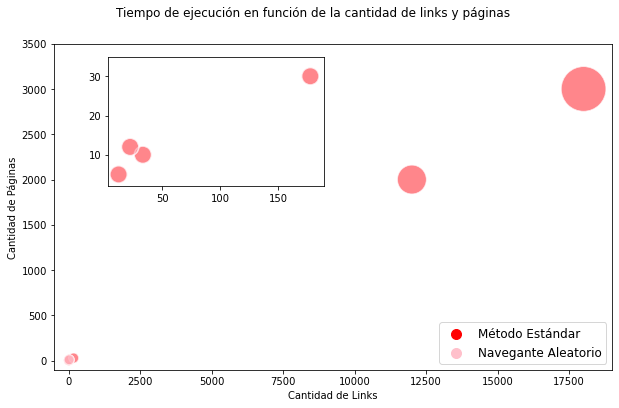

Concluimos que la cantidad de links no influye significativamente en el tiempo de ejecución, al menos no tanto como lo hace la cantidad de páginas. Esto tiene sentido, ya que el aumento en la cantidad de páginas resulta en un incremento notable en la cantidad de operaciones al iterar sobre más elementos. Por otro lado, no encontramos diferencias discernibles en los tiempos de ejecución al resolver el sistema utilizando el método estándar o el de navegante aleatorio, al menos según los tests proporcionados.

### Análisis Cualitativo

Para el análisis cualitativo se deberán estudiar los rankings obtenidos, en función de la estructura del grafo, y del valor de $p$. Para esto, se espera que presenten gráficos mostrando las probabilidades de las páginas mejor rankeadas en función del valor de $p$.


Para realizar un análisis cuantitativo de los rankings obtenidos, comenzamos por realizar los grafos de los test dados, los cuales se pueden apreciar en la siguiente figura:
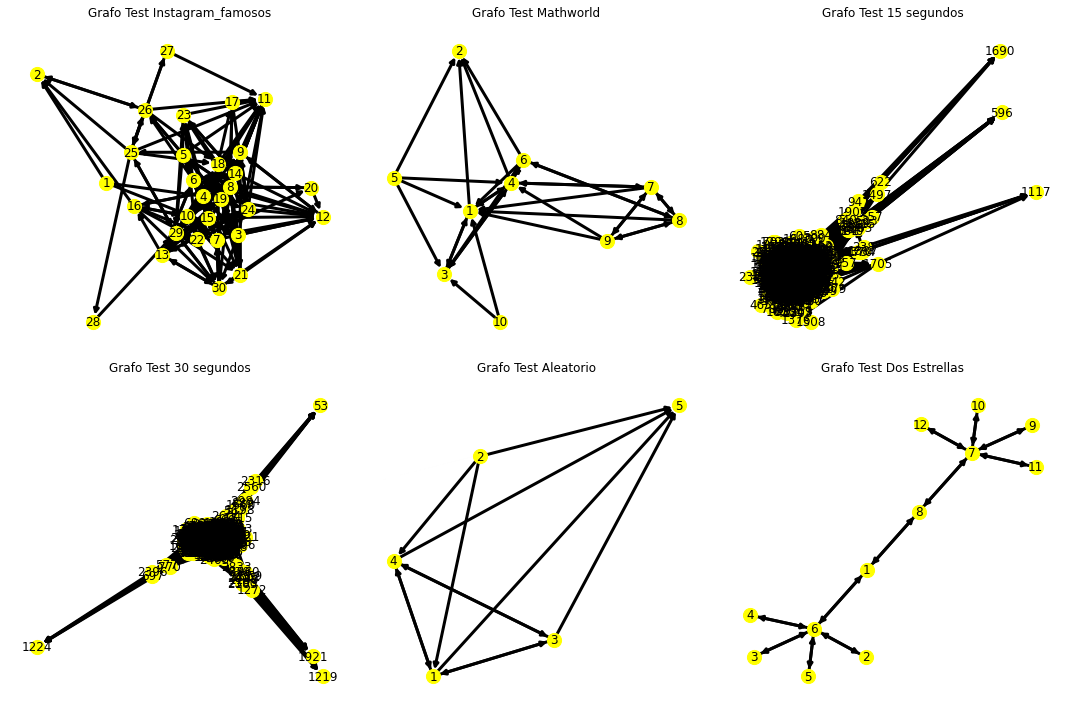

ME FALTA DESARROLLAR SOBRE LA DENSIDAD DE LOS GRAFOS Y CUANTOS NODOS CONECTADOS HAY

Luego, nos propusimos ver si al aumentar la probabilidad p, era posible que cambiara en algun momento la pagina con mejor ranking, es decir la primer posicion. Para ello, realizamos el siguiente grafico

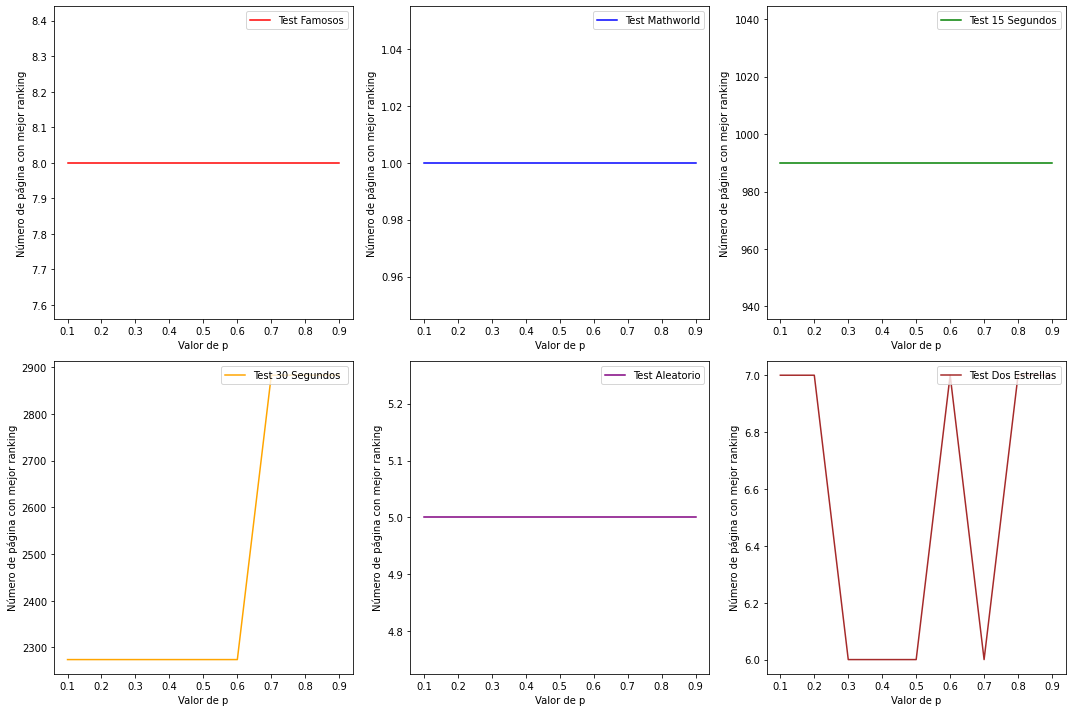

En el, podemos observar como al aumentar la probabilidad de seguir un link u otro, la pagina con mejor puntaje (la primera en el ranking) sigue siendo la misma. Esto tiene sentido, ya que al aumentar la probabilidad que tiene cada pagina de ser elegida, la cual se ve afectada por la cantidad de enlaces o links a otras paginas, determinando así a su importancia

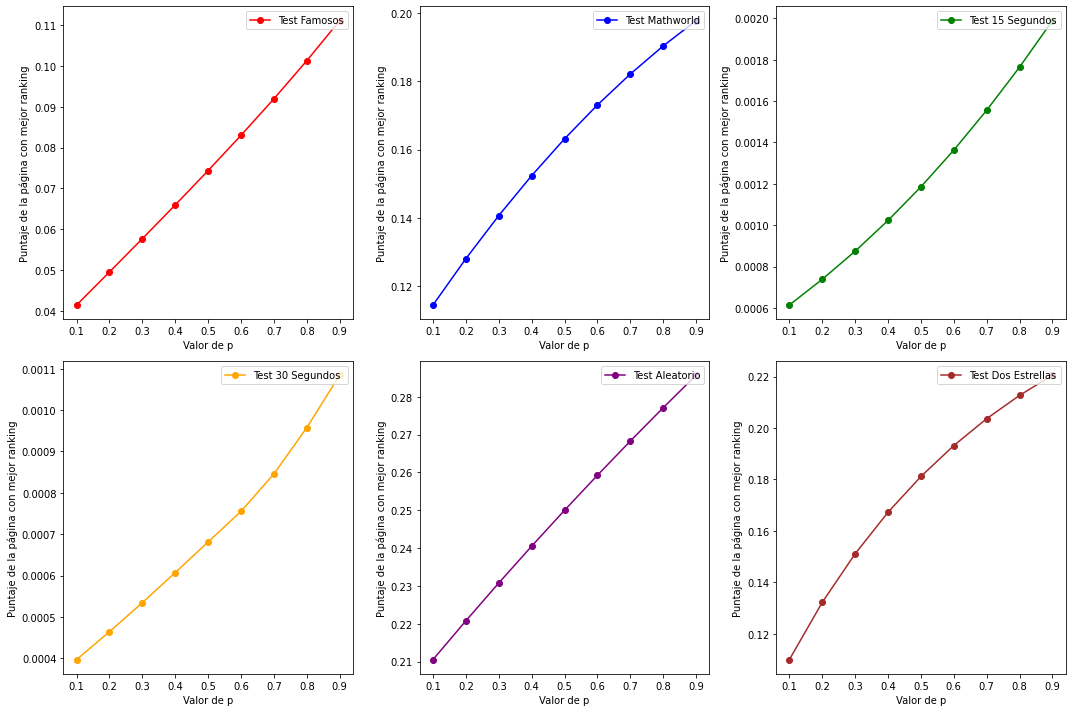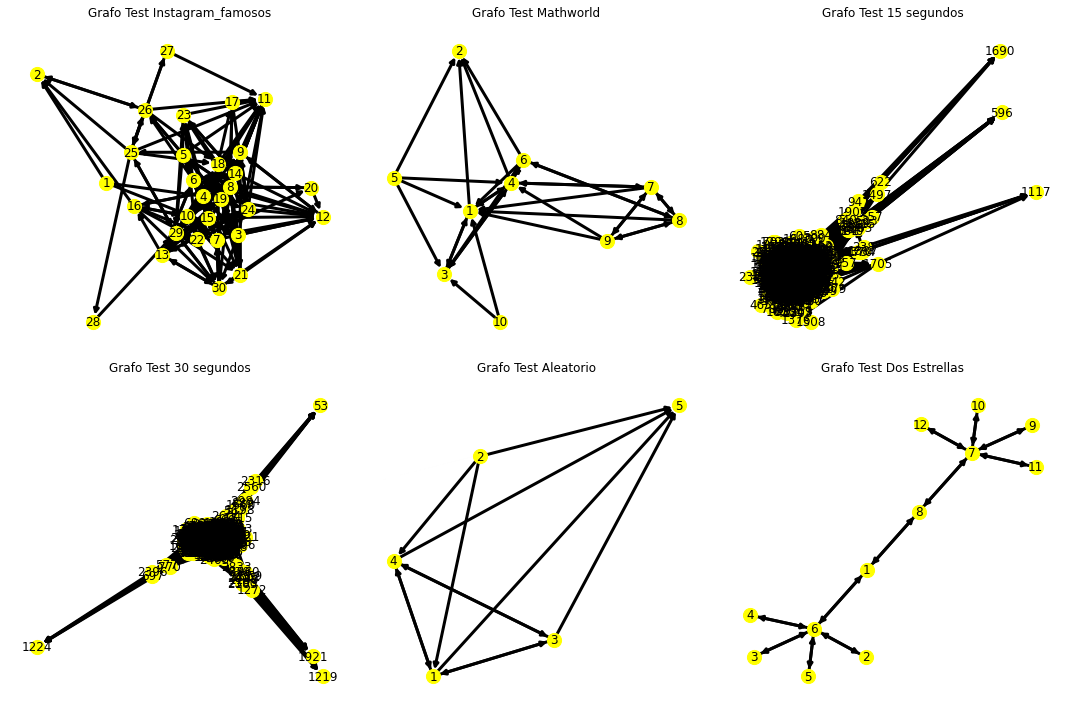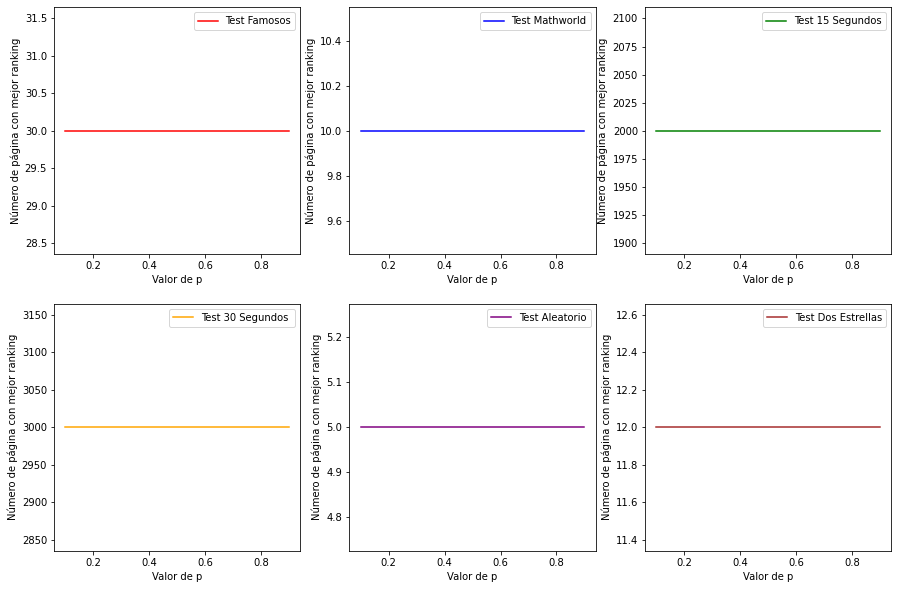

### Dos estrellas

Para el caso **test_dosestrellas.txt** se pregunta:

¿Cuál es la mínima cantidad de links que se deben agregar para que la pagina correspondiente al nodo 1 quede primera en el ranking? ¿ Cómo se modificó la conectividad? Analizar.


---




Dado que la estructura del grafo es simétrica, podemos anticipar que los nodos en disposiciones similares tendrán puntajes similares. Esta intuición se puede confirmar al ejecutar la función **calcularRanking**. En el modelado del problema, se explica el carácter recursivo del cálculo del puntaje de una página, que se ve influenciado no solo por la cantidad de links hacia esa página, sino también por la importancia de las páginas desde donde salen esos links. Por lo tanto, exploramos la posibilidad de añadir links estratégicamente, redistribuyendo los puntajes de las páginas con mejor ranking hacia la página 1.

Valiéndonos de la estructura simétrica, agregamos enlaces de manera que los puntajes concentrados en los 2 nodos principales (páginas 6 y 7) se distribuyan de manera equitativa. De esta forma, determinamos que la mínima cantidad de enlaces que se deben agregar para que la página asociada al nodo 1 ocupe el primer lugar en el ranking es **6**.



3
1
Ejes:  [(1, 6), (1, 8), (2, 1), (2, 6), (3, 1), (3, 6), (4, 1), (4, 6), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (7, 1), (7, 8), (7, 9), (7, 10), (7, 11), (7, 12), (8, 1), (8, 7), (9, 7), (10, 7), (11, 1), (11, 7), (12, 1), (12, 7)]


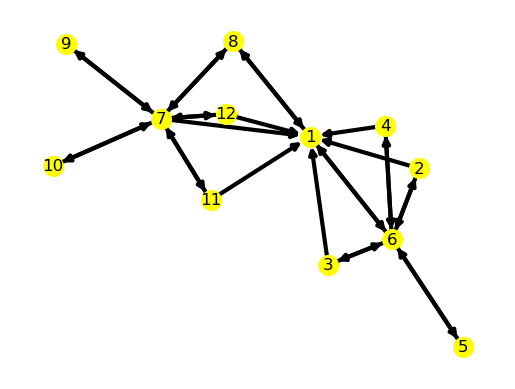

In [69]:
#Cantidad minima de links para que ranking de la pagina 1 sea 1 : 6

archivo_test = './tests/test_dosestrellas.txt'
W = leer_archivo(archivo_test)

rnk, scr = calcularRanking(W,p)
rankingPag1 = rnk[0]
print(rankingPag1)

W[0][1]=1
W[0][2]=1
W[0][3]=1
W[0][6]=1
W[0][10]=1
W[0][11]=1

rnk, scr = calcularRanking(W,p)
rankingPag1 = rnk[0]
print(rankingPag1)
dibujarGrafo(W)